Restart 1/4, Best Value: -0.000488191274500173
Restart 2/4, Best Value: -0.0016212990603096148
Restart 3/4, Best Value: -0.0016212990603096148
Restart 4/4, Best Value: -0.0016212990603096148
iteration 0
height: [2.20691359 1.41873544 1.89144364 1.79214213 1.9535913 ]
area: [0.00535841]
weight: 2378.7204182991172
freq1: 25.937768751066496
freq2: 55.90618320273185
freq3: 69.41929534006634
Restart 1/4, Best Value: -0.00036245431256033575
Restart 2/4, Best Value: -0.009820226721782276
Restart 3/4, Best Value: -0.009820226721782276
Restart 4/4, Best Value: -0.009820226721782276
iteration 1
height: [1.16411833 1.87093262 2.48498323 2.32023289 2.77026052]
area: [0.00295799]
weight: 1344.1705934410097
freq1: 33.262202337406876
freq2: 59.13089879885223
freq3: 92.05909653883408
Restart 1/4, Best Value: -0.015106989499191986
Restart 2/4, Best Value: -0.015106989499191986
Restart 3/4, Best Value: -0.015106989499191986
Restart 4/4, Best Value: -0.015106989499191986
iteration 2
height: [1.35500626 1

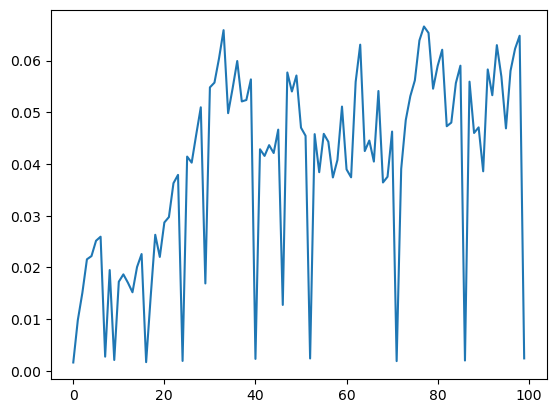

In [48]:
import numpy as np
import time
from scipy.optimize import minimize, differential_evolution
from scipy.stats import norm
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, RBF, WhiteKernel, ConstantKernel, RationalQuadratic, DotProduct
from sklearn.preprocessing import MinMaxScaler, StandardScaler
import matplotlib.pyplot as plt

import sys
sys.path.append('../pyJive/')

from utils import proputils as pu
import main
from names import GlobNames as gn
from names import ParamNames as pn

import io
import contextlib


def update_geom_file(geom_path, y_coord, update_lines, output_path=None):
    output_path = output_path or geom_path  # Overwrite if no output path provided

    # Read the .geom file
    with open(geom_path, 'r') as file:
        lines = file.readlines()

    # Locate and modify the section with upper node coordinates
    for i in range(len(lines)):
        if i in update_lines:
            parts = lines[i].split()
            parts[-1] = str(y_coord)  # Modify the last value
            lines[i] = ' '.join(parts) + '\n'        
            
    # Write back the updated file
    with open(output_path, 'w') as file:
        file.writelines(lines)
        

def finite_element_solver(x, n_heights, n_areas):
    # DOES ONLY WORK FOR 6 DIMENSIONS
    y_coord = x[:n_heights]
    area = x[n_heights:]
    update_lines = [[3, 19], [5, 17], [7, 15], [9, 13], [11,]]
    
    for i in range(n_heights):
        update_geom_file('bridge.geom', y_coord[i], update_lines[i], output_path=None)
    
    # Load properties
    props = pu.parse_file('bridge_frequency.pro')
    
    # Update cross-section area
    props['model']['truss']['area'] = [area] * 15
    # props['model']['truss']['area'] = [4e-3] * [area] * 15
    
    # Run FEM simulation
    with contextlib.redirect_stdout(io.StringIO()):
        globdat = main.jive(props)

    # Extract mass  
    mass_nodes = props['model']['mass']['nodeGroup']
    n_bottom_nodes = len(globdat[gn.NGROUPS][mass_nodes])
    point_mass = float(props['model']['mass']['mass'])
    weight = 0.5 * np.sum(globdat[pn.MATRIX2]) - n_bottom_nodes * point_mass
    
    # Extract natural frequencies
    freq1 = globdat[gn.EIGENFREQS][0] / (2 * np.pi)
    freq2 = globdat[gn.EIGENFREQS][1] / (2 * np.pi)
    freq3 = globdat[gn.EIGENFREQS][2] / (2 * np.pi)

    return weight, freq1, freq2, freq3


def feasibility_probability(x, gp_freq, threshold):
    mu, sigma = gp_freq.predict(x.reshape(1, -1), return_std=True)
    prob = norm.cdf((threshold - mu) / (sigma + 1e-9))
    
    # return prob >= 0.05
    return prob


def EI(x, gp_Y, gp_freq1, gp_freq2, gp_freq3, Y_samples, threshold1, threshold2, threshold3, input_scaler, output_scaler, n_dim):
    mu, sigma = gp_Y.predict(x.reshape(1, -1), return_std=True)
    mu, sigma = mu[0], sigma[0]
    best = np.min(Y_samples)
    
    # Expected Improvement (EI)
    xi = 4
    z = (best - mu) / (sigma + 1e-9)
    ei = (best - mu) * norm.cdf(z) + sigma * norm.pdf(z)
    
    prob1 = 1 - feasibility_probability(x, gp_freq1, threshold1)
    prob2 = 1 - feasibility_probability(x, gp_freq2, threshold2)
    prob3 = 1 - feasibility_probability(x, gp_freq3, threshold3)
    
    # print('x', input_scaler.inverse_transform(x.reshape(-1, n_dim))[0])
    # print('mu', output_scaler.inverse_transform(mu.reshape(-1, 1))[0, 0])
    # print(f"x:, {x}, mu: {mu}, sigma: {sigma}, best: {best}, z: {z}, ei: {ei}, prob1: {prob1}, prob2: {prob2}, prob3: {prob3}")
    
    return -ei * prob1 * prob2 * prob3
    # return -ei
    
    
def restart_differential_evolution(acquisition_func, bounds, n_restarts=4):
    best_x = None
    best_value = float('inf')
    
    for restart in range(n_restarts):
        result = differential_evolution(
            lambda x: acquisition_func(x), 
            bounds=bounds, 
            strategy='best1bin', 
            popsize=5,  # 5 * 19 = 95 population size
            maxiter=10,  # Small maxiter, we restart after 10 iterations
            tol=1e-6, 
            polish=True
        )
        if result.fun < best_value:
            best_value = result.fun
            best_x = result.x

        print(f"Restart {restart + 1}/{n_restarts}, Best Value: {best_value}")
    
    return best_x


def bayesian_optimization(n_iter=100):
    n_heights = 5
    n_areas = 1
    n_dim = n_heights + n_areas
    
    n_init = 100
    
    bounds_height_unscaled = np.tile([0.2, 3], (n_heights, 1))
    bounds_area_unscaled = np.tile([1e-5, 1e-2], (n_areas, 1))
    bounds_unscaled = np.vstack((bounds_height_unscaled, bounds_area_unscaled))
    
    threshold1_unscaled = 20
    threshold2_unscaled = 40
    threshold3_unscaled = 60
    
    X_height_unscaled = np.random.uniform(bounds_height_unscaled[0][0], bounds_height_unscaled[0][1], size=(n_init, n_heights))
    X_area_unscaled = np.random.uniform(bounds_area_unscaled[0][0], bounds_area_unscaled[0][1], size=(n_init, n_areas))
    X_samples_unscaled = np.column_stack((X_height_unscaled, X_area_unscaled))
    
    output = np.array([finite_element_solver(x, n_heights, n_areas) for x in X_samples_unscaled])
    
    Y_samples_unscaled = output[:, 0]
    freq1_samples_unscaled = output[:, 1]
    freq2_samples_unscaled = output[:, 2]
    freq3_samples_unscaled = output[:, 3]
    
    input_scaler = StandardScaler()
    output_scaler = StandardScaler()
    freq1_scaler = StandardScaler()
    freq2_scaler = StandardScaler()
    freq3_scaler = StandardScaler()
    
    X_samples = input_scaler.fit_transform(X_samples_unscaled)
    Y_samples = output_scaler.fit_transform(Y_samples_unscaled.reshape(-1, 1)).flatten()
    freq1_samples = freq1_scaler.fit_transform(freq1_samples_unscaled.reshape(-1, 1)).flatten()
    freq2_samples = freq2_scaler.fit_transform(freq2_samples_unscaled.reshape(-1, 1)).flatten()
    freq3_samples = freq3_scaler.fit_transform(freq3_samples_unscaled.reshape(-1, 1)).flatten()
    
    bounds = input_scaler.transform(bounds_unscaled.T).T
    threshold1 = freq1_scaler.transform(np.array(threshold1_unscaled).reshape(-1, 1))[0, 0]
    threshold2 = freq2_scaler.transform(np.array(threshold2_unscaled).reshape(-1, 1))[0, 0]
    threshold3 = freq3_scaler.transform(np.array(threshold3_unscaled).reshape(-1, 1))[0, 0]
    
    kernel_Y = RBF(length_scale=0.3) + WhiteKernel(noise_level=1e-3)
    kernel_freq1 = RBF(length_scale=0.3) + WhiteKernel(noise_level=1e-6)
    kernel_freq2 = RBF(length_scale=0.3) + WhiteKernel(noise_level=1e-6)
    kernel_freq3 = RBF(length_scale=0.3) + WhiteKernel(noise_level=1e-6)
    
    gp_Y = GaussianProcessRegressor(kernel=kernel_Y, optimizer=None, alpha=0)
    gp_freq1 = GaussianProcessRegressor(kernel=kernel_freq1, optimizer=None, alpha=0)
    gp_freq2 = GaussianProcessRegressor(kernel=kernel_freq2, optimizer=None, alpha=0)
    gp_freq3 = GaussianProcessRegressor(kernel=kernel_freq3, optimizer=None, alpha=0)
    
    EI_list = []
    for iteration in range(n_iter):

        gp_Y.fit(X_samples, Y_samples)
        gp_freq1.fit(X_samples, freq1_samples)
        gp_freq2.fit(X_samples, freq2_samples)
        gp_freq3.fit(X_samples, freq3_samples)
        
        def acquisition(x):
            return EI(x, gp_Y, gp_freq1, gp_freq2, gp_freq3, Y_samples, threshold1, threshold2, threshold3, input_scaler, output_scaler, n_dim)
        
        # x_next = minimize(acquisition, np.random.uniform(bounds[0][0], bounds[0][1], 1), bounds=bounds).x
        # x_next = differential_evolution(acquisition, bounds=bounds).x
        # x_next = differential_evolution(lambda x: acquisition(x), 
        #                             bounds=bounds, 
        #                             strategy='best1bin', 
        #                             popsize=5, 
        #                             maxiter=10, 
        #                             tol=1e-6, 
        #                             polish=True).x
        x_next = restart_differential_evolution(acquisition, bounds)
        
        EI_list.append(-acquisition(x_next))
        x_next_unscaled = input_scaler.inverse_transform(x_next.reshape(-1, n_dim))[0]
        
        y_next_unscaled = finite_element_solver(x_next_unscaled, n_heights, n_areas)[0]
        freq1_next_unscaled = finite_element_solver(x_next_unscaled, n_heights, n_areas)[1]
        freq2_next_unscaled = finite_element_solver(x_next_unscaled, n_heights, n_areas)[2]
        freq3_next_unscaled = finite_element_solver(x_next_unscaled, n_heights, n_areas)[3]
        
        y_next = output_scaler.transform(y_next_unscaled.reshape(-1, 1))[0]
        freq1_next = freq1_scaler.transform(freq1_next_unscaled.reshape(-1, 1))[0]
        freq2_next = freq2_scaler.transform(freq2_next_unscaled.reshape(-1, 1))[0]
        freq3_next = freq3_scaler.transform(freq3_next_unscaled.reshape(-1, 1))[0]
        
        X_samples = np.vstack((X_samples, x_next))
        Y_samples = np.append(Y_samples, y_next)        
        freq1_samples = np.append(freq1_samples, freq1_next)
        freq2_samples = np.append(freq2_samples, freq2_next)
        freq3_samples = np.append(freq3_samples, freq3_next)
        
        # print(f'x_next_unscaled: {x_next_unscaled}, y_next_unscaled: {y_next_unscaled}')
        
        # plot(iteration, n_init, gp_Y, gp_freq1, gp_freq2, gp_freq3, x_next, bounds, X_samples, Y_samples, freq1_samples, freq2_samples, freq3_samples, threshold1, threshold2, threshold3)
    
        print(f'iteration {iteration}')
        print(f'height: {x_next_unscaled[:n_heights]}')
        print(f'area: {x_next_unscaled[n_heights:]}')
        print(f'weight: {y_next_unscaled}')
        print(f'freq1: {freq1_next_unscaled}')
        print(f'freq2: {freq2_next_unscaled}')
        print(f'freq3: {freq3_next_unscaled}')
    
    plt.plot(EI_list)
    valid_idx = np.where((freq1_samples >= threshold1) & (freq2_samples >= threshold2) & (freq3_samples >= threshold3))[0]
    best_idx = valid_idx[np.argmin(Y_samples[valid_idx])]
    best_x_unscaled = input_scaler.inverse_transform(X_samples[best_idx].reshape(-1, n_dim))[0]
    best_y_unscaled = output_scaler.inverse_transform(Y_samples[best_idx].reshape(-1, 1))[0, 0]
    best_freq1_unscaled = freq1_scaler.inverse_transform(freq1_samples[best_idx].reshape(-1, 1))[0, 0]
    best_freq2_unscaled = freq2_scaler.inverse_transform(freq2_samples[best_idx].reshape(-1, 1))[0, 0]
    best_freq3_unscaled = freq3_scaler.inverse_transform(freq3_samples[best_idx].reshape(-1, 1))[0, 0]
              
    
    return best_x_unscaled[:n_heights], best_x_unscaled[n_heights:], best_y_unscaled, best_freq1_unscaled, best_freq2_unscaled, best_freq3_unscaled

start_time = time.time()
height, area, weight, freq1, freq2, freq3 = bayesian_optimization()
end_time = time.time()
print(f'time: {end_time - start_time}')
print(f'height: {height}')
print(f'area: {area}')
print(f'weight: {weight}')
print(f'freq1: {freq1}')
print(f'freq2: {freq2}')
print(f'freq3: {freq3}')

In [ ]:
'''
Results:

1D 10 iter
height: 0.8801171724833711
weight: 306.0914165382799
freq1: 20.01382018539408
freq2: 60.53701911907595
freq3: 77.98432583380647

2D 10 iter
(1.45892608e+00, 
 8.26994773e-04,
 314.90212933141584,
 26.93075427793534,
 57.98609692480615,
 87.46336305869983)

2D 20 iter
(1.70255664e+00, 
 2.62657156e-04,
 108.72205540023697,
 23.656477373769974,
 46.001455497092266,
 71.12298925162631)
 
2D 30 iterations
height: 1.7025566449879144
area: 0.00026265715620093014
weight: 108.72205540023697
freq1: 23.656477373769974
freq2: 46.001455497092266
freq3: 71.12298925162631

2D 50? iter
height: 1.6245887541962594
area: 0.00015735627328516359
weight: 63.45330407099618
freq1: 20.15296358267792
freq2: 40.24310262961319
freq3: 61.02106478968211

2D 30 iter
height: 1.8445039424674605
area: 0.00018786620512723472
weight: 81.44735652588815
freq1: 22.43944437685939
freq2: 41.612074208406824
freq3: 64.9237041901398
'''